In [1]:
## Install modules in the terminal if running remotely
## pip install numpy
## pip install matplotlib

In [2]:
import numpy as np
import pickle
import os.path
import matplotlib.pyplot as plt
plt.rcParams["image.cmap"] = "binary"

In [3]:
## 8 possibilities for a binary triplet (three-cell neighbor): 2^3 = 8
## 256 possible binary output rules: 2^8 = 256

def WolframCode(rule_number):
    rule_string = np.binary_repr(rule_number, 8)
    rule_array = np.array([int(bit) for bit in rule_string])
    return rule_array

## print(WolframCode(150))
## [1 0 0 1 0 1 1 0]

In [4]:
## input:111, index:0, output --> ?
## input:110, index:1, output --> ?
## input:101, index:2, output --> ?
## input:100, index:3, output --> ?
## input:011, index:4, output --> ?
## input:010, index:5, output --> ?
## input:001, index:6, output --> ?
## input:000, index:7, output --> ?

def rule_internalIndex(triplet):
    L, C, R = triplet
    index = 7 - (4 * L + 2 * C + R)
    return int(index)

## print(rule_internalIndex((1, 1, 1)))  # 0
## print(rule_internalIndex((1, 0, 0)))  # 3
## print(rule_internalIndex((0, 0, 1)))  # 6

In [5]:
## Apply the rule to a binary vector, and generate a new binary vector

def StepOne(vector, rule_array):
    triplets = np.stack([np.roll(vector, 1), vector, np.roll(vector, -1)])  ## create rolling triplets
    new_vector = rule_array[np.apply_along_axis(rule_internalIndex, 0, triplets)]  ## apply the rule and generate a new binary vector
    return new_vector

In [6]:
## Apply the same rule consecutively for a specific number of times

def StepMany(initial_vector, rule_array, n_iteration):

    result = np.zeros((n_iteration, len(initial_vector)))
    result[0, :] = initial_vector

    for step in range(1, n_iteration):
        result[step, :] = StepOne(result[step - 1, :], rule_array)

    return result

In [7]:
## Count the frequency of 1's in each column

def GetFreqPerColumn(matrix):
    return np.sum(matrix, axis=0) / matrix.shape[0]

In [8]:
## Try and guess the rule that generated the pattern, using statistics (frequency) as the signature
## Return (True/False if guessed correctly/incorrectly, set(guesses))

def GuessTheRule(mystery, correct_rule_number, verbose=False):
    
    mystery_signature = GetFreqPerColumn(mystery)
    ## print(signature)
    ## print()
    
#    ## perfect match
#    if verbose:
#        print("Exactly Matching Rules: ")
#    
#    #for k, v in repository[string_initial_vector].items():
#        #freq = v["freq"]
#        #if (np.array_equal(signature, freq)):  ## if (signature == v):
#            #if verbose:
#                #print(k)

    
    ## close match
    ## numpy.isclose()
    ## e (epsilon: error, maybe 0.5%)
    guesses = set()
    
    for rule_number in range(0, 256):
        rule_freq = repository[string_initial_vector][rule_number]['freq']
        if (np.isclose(mystery_signature, rule_freq, 0.005, 0.005).all()):
            guesses.add(rule_number)

    if correct_rule_number in guesses:
        if verbose:
            print("Correct guess! ", correct_rule_number)
        return (True, guesses)
    else:
        if verbose:
            print("Failed to guess right...")
        return (False, guesses)

In [9]:
## Find the minimum repeating segment (pure segment)

def GetPureSegment_failed(nparray):
    first_row = nparray[0]
    for i in range(1, len(nparray)):

        if (np.array_equal(first_row, nparray[i])):
            return nparray[0:i]
    return None

In [10]:
## Find the minimum repeating segment (pure segment)

def GetPureSegment(nparray):
    for i in range(0, len(nparray) - 1):
        first_row = nparray[i]
        
        for j in range(i + 1, len(nparray)):
            if (np.array_equal(first_row, nparray[j])):
                return nparray[i:j]
    return None

In [11]:
## Visualize a binary vector as a black/white pattern

def Visualize(numpy_binary_array, title=None):
    fig, ax = plt.subplots(figsize=(4, 4))
    if title is not None:
        ax.set_title(str(title))
    ax.axis(False)
    ax.matshow(numpy_binary_array)

# START HERE

In [12]:
## Load the result of previous computations

if os.path.isfile("repository.pkl"):
    with open("repository.pkl", 'rb') as file:
        repository = pickle.load(file)
else:
    repository = {}

In [13]:
vector_length = 10

rng = np.random.RandomState(99)
initial_vector = rng.randint(0, 2, vector_length)  # a binary vector (0 or 1) of length X
print("Initial vector:")
print(initial_vector)

Initial vector:
[1 1 1 0 1 0 0 0 1 0]


In [14]:
steps = 10000

string_initial_vector = "".join(initial_vector.astype(str))
if not (string_initial_vector in repository.keys()):
    
    repository[string_initial_vector] = {}
    for rule_number in range(0, 256):
    
        data = StepMany(initial_vector, WolframCode(rule_number), steps)
        freq = GetFreqPerColumn(data)
        combined = {}
        combined["data"] = data
        combined["freq"] = freq
        repository[string_initial_vector][rule_number] = combined

    ## save (pickle) the computation result
    with open('repository.pkl', 'wb') as file:
        pickle.dump(repository, file)

else:
    print("The initial vector [", string_initial_vector, "] already exists in the computation repository.")

The initial vector [ 1110100010 ] already exists in the computation repository.


In [15]:
# repository -- initial_vector -- 256 rules -- 'data'  len: steps
#                                           -- 'freq'  len: vector_length

print(repository.keys())
print(len(repository['1110100010'].keys()))
print(repository['1110100010'][10].keys())
print(repository['1110100010'][10]['freq'])
print(len(repository['1110100010'][10]['data']))
print(repository['1110100010'][10]['data'][5000:5020])

dict_keys(['0100000110', '1110100010'])
256
dict_keys(['data', 'freq'])
[0.2001 0.2    0.2001 0.2    0.2001 0.2    0.2    0.2    0.2    0.2   ]
10000
[[0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]]


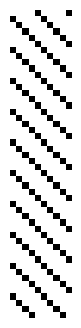

In [16]:
# visualize as a pattern

x = repository['1110100010'][24]['data']
Visualize(x[5000:5050])

# Test guessing one segment

In [17]:
random_integer = int(rng.randint(0, 256))  ## Pick a random integer from low (inclusive) to high (exclusive)

rule_number = random_integer
print("Rule Number:", rule_number)

Rule Number: 129


In [18]:
length_mystery = int(steps * 0.05)

##random_startingIndex = int(rng.randint(0, steps - length_mystery + 1))
##mystery = repository[string_initial_vector][random_integer]["data"][random_startingIndex: random_startingIndex + length_mystery]

startingIndex = int(steps/2)
mystery = repository[string_initial_vector][rule_number]['data'][startingIndex : (startingIndex + length_mystery)]

##-------------------------------------------------##

#print("Starting Index :", startingIndex)
print("Mystery segment shape:", mystery.shape)
#Visualize(mystery, "Mystery")

Mystery segment shape: (500, 10)


In [19]:
correct_answer = rule_number
result, guesses = GuessTheRule(mystery, correct_answer, True)

Correct guess!  129


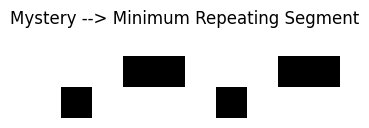

In [20]:
mystery_pure = GetPureSegment(mystery)
#print(mystery_pure)

Visualize(mystery_pure, "Mystery --> Minimum Repeating Segment")

In [21]:
correct_answer = rule_number
GuessTheRule(mystery_pure, correct_answer, True)

Correct guess!  129


(True, {129})

# Repeat for all rules: Guess which rule generated the segment

In [22]:
length_mystery = int(steps * 0.05)
#length_mystery = 1024

dict_incorrectGuesses = {}

for i in range(0, 256):

    #random_startingIndex = int(rng.randint(0, steps - length_mystery + 1))
    startingIndex = int(steps/2)
    mystery = repository[string_initial_vector][i]["data"][startingIndex: (startingIndex + length_mystery)]
    ## mystery_pure = GetPureSegment(mystery)
    result, guesses = GuessTheRule(mystery, i, True)
    if (result == True):
        pass
    else:
        print("Rule ", i, ": Failed to guess right...")
        dict_incorrectGuesses[i] = guesses

Correct guess!  0
Correct guess!  1
Correct guess!  2
Correct guess!  3
Correct guess!  4
Correct guess!  5
Correct guess!  6
Correct guess!  7
Correct guess!  8
Correct guess!  9
Correct guess!  10
Correct guess!  11
Correct guess!  12
Correct guess!  13
Correct guess!  14
Correct guess!  15
Correct guess!  16
Correct guess!  17
Correct guess!  18
Correct guess!  19
Correct guess!  20
Correct guess!  21
Correct guess!  22
Correct guess!  23
Correct guess!  24
Correct guess!  25
Correct guess!  26
Correct guess!  27
Correct guess!  28
Correct guess!  29
Correct guess!  30
Correct guess!  31
Correct guess!  32
Correct guess!  33
Correct guess!  34
Correct guess!  35
Correct guess!  36
Correct guess!  37
Correct guess!  38
Correct guess!  39
Correct guess!  40
Correct guess!  41
Correct guess!  42
Correct guess!  43
Correct guess!  44
Failed to guess right...
Rule  45 : Failed to guess right...
Correct guess!  46
Correct guess!  47
Correct guess!  48
Correct guess!  49
Correct guess!  50

# Repeat for all rules: Guess which rule generated the segment, using pure segment

In [23]:
length_mystery = int(steps * 0.05)
#length_mystery = 1024

dict_incorrectGuesses = {}

for i in range(0, 256):

    #random_startingIndex = int(rng.randint(0, steps - length_mystery + 1))
    startingIndex = int(steps/2)
    mystery = repository[string_initial_vector][i]["data"][startingIndex: (startingIndex + length_mystery)]
    mystery_pure = GetPureSegment(mystery)
    result, guesses = GuessTheRule(mystery_pure, i, True)
    if (result == True):
        pass
    else:
        print("Rule ", i, ": Failed to guess right...")
        dict_incorrectGuesses[i] = guesses

Correct guess!  0
Correct guess!  1
Correct guess!  2
Correct guess!  3
Correct guess!  4
Correct guess!  5
Correct guess!  6
Correct guess!  7
Correct guess!  8
Correct guess!  9
Correct guess!  10
Correct guess!  11
Correct guess!  12
Correct guess!  13
Correct guess!  14
Correct guess!  15
Correct guess!  16
Correct guess!  17
Correct guess!  18
Correct guess!  19
Correct guess!  20
Correct guess!  21
Correct guess!  22
Correct guess!  23
Correct guess!  24
Correct guess!  25
Correct guess!  26
Correct guess!  27
Correct guess!  28
Correct guess!  29
Correct guess!  30
Correct guess!  31
Correct guess!  32
Correct guess!  33
Correct guess!  34
Correct guess!  35
Correct guess!  36
Correct guess!  37
Correct guess!  38
Correct guess!  39
Correct guess!  40
Correct guess!  41
Correct guess!  42
Correct guess!  43
Correct guess!  44
Correct guess!  45
Correct guess!  46
Correct guess!  47
Correct guess!  48
Correct guess!  49
Correct guess!  50
Correct guess!  51
Correct guess!  52
Cor

# Pure on Pure

In [25]:
## Try and guess the rule that generated the pattern, using statistics (frequency) 
## of the pure (minimum repeating) segment of everything as the signature
## Return (True/False if guessed correctly/incorrectly, set(guesses))

pure_data = {}
pure_data_freq = {}
for i in range(0, 256):
    pure_data[i] = GetPureSegment(repository[string_initial_vector][i]['data'])
    pure_data_freq[i] = GetFreqPerColumn(pure_data[i])


def GuessTheRule_Pure(mystery, correct_rule_number, verbose=False):
    
    mystery_signature = GetFreqPerColumn(mystery)
    ## print(signature)
    ## print()

    
    ## close match
    ## numpy.isclose()
    ## e (epsilon: error, maybe 0.5%)
    guesses = set()
    
    for rule_number in range(0, 256):
        #rule_freq = repository[string_initial_vector][rule_number]['freq']
        rule_freq = pure_data_freq[rule_number]
        if (np.isclose(mystery_signature, rule_freq, 0.005, 0.005).all()):
            guesses.add(rule_number)

    if correct_rule_number in guesses:
        if verbose:
            print("Correct guess! ", correct_rule_number)
        return (True, guesses)
    else:
        if verbose:
            print("Failed to guess right...")
        return (False, guesses)

In [27]:
length_mystery = int(steps * 0.05)
#length_mystery = 1024

dict_incorrectGuesses = {}
arr_guesses = {}

for i in range(0, 256):

    #random_startingIndex = int(rng.randint(0, steps - length_mystery + 1))
    startingIndex = int(steps/2)
    mystery = repository[string_initial_vector][i]["data"][startingIndex: (startingIndex + length_mystery)]
    mystery_pure = GetPureSegment(mystery)
    result, guesses = GuessTheRule_Pure(mystery_pure, i, True)
    if (result == True):
        pass
    else:
        print("Rule ", i, ": Failed to guess right...")
        dict_incorrectGuesses[i] = guesses
    arr_guesses[i] = guesses

Correct guess!  0
Correct guess!  1
Correct guess!  2
Correct guess!  3
Correct guess!  4
Correct guess!  5
Correct guess!  6
Correct guess!  7
Correct guess!  8
Correct guess!  9
Correct guess!  10
Correct guess!  11
Correct guess!  12
Correct guess!  13
Correct guess!  14
Correct guess!  15
Correct guess!  16
Correct guess!  17
Correct guess!  18
Correct guess!  19
Correct guess!  20
Correct guess!  21
Correct guess!  22
Correct guess!  23
Correct guess!  24
Correct guess!  25
Correct guess!  26
Correct guess!  27
Correct guess!  28
Correct guess!  29
Correct guess!  30
Correct guess!  31
Correct guess!  32
Correct guess!  33
Correct guess!  34
Correct guess!  35
Correct guess!  36
Correct guess!  37
Correct guess!  38
Correct guess!  39
Correct guess!  40
Correct guess!  41
Correct guess!  42
Correct guess!  43
Correct guess!  44
Correct guess!  45
Correct guess!  46
Correct guess!  47
Correct guess!  48
Correct guess!  49
Correct guess!  50
Correct guess!  51
Correct guess!  52
Cor

# Start clustering rules

In [28]:
count = 0
for i in range(0, 256):
    for j in range(0, 256):
        a = set()
        if i > j:
            ##a = arr_guesses[i].intersection(arr_guesses[j])
            a = arr_guesses[i] & arr_guesses[j]
        if len(a) > 0:
            ## print(i, j, a)
            count = count + 1

print(count)

867


In [29]:
count = 0
for i in range(0, 256):
    for j in range(0, 256):
        a = set()
        if i > j:
            a = arr_guesses[i].intersection(arr_guesses[j])
        if len(a) > 0:
            if (arr_guesses[i] == arr_guesses[j]):
                count = count + 1

print(count)

867


In [30]:
count = 0
for i in range(0, 256):
    for j in range(0, 256):
        a = set()
        if i > j:
            a = arr_guesses[i].intersection(arr_guesses[j])
            b = arr_guesses[i].union(arr_guesses[j])
            
        if len(a) > 0:
            if not (a == b):
                count = count + 1
                print("i:", i, "j:", j, "guesses for i:", arr_guesses[i], "guesses for j:", arr_guesses[j], "inter:", a, "union:", b)

print(count)

0


In [31]:
arr_guesses[0]

{0, 8, 32, 36, 40, 64, 72, 96, 104, 128, 136, 160, 168, 192, 224}

In [32]:
arr_guesses[8]

{0, 8, 32, 36, 40, 64, 72, 96, 104, 128, 136, 160, 168, 192, 224}

In [33]:
print(arr_guesses[255])
print(arr_guesses[254])
arr_guesses[254] == arr_guesses[254]

{233, 234, 235, 237, 238, 239, 251, 248, 249, 250, 219, 252, 253, 254, 255}
{233, 234, 235, 237, 238, 239, 251, 248, 249, 250, 219, 252, 253, 254, 255}


True

In [34]:
arr_guesses[100]

{100}

In [35]:
arr_guesses[150]

{150}

In [36]:
arr_guesses[12]

{12, 140}